<a href="https://colab.research.google.com/github/BenT034/Afstuderen_tests/blob/main/embedding_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Embedding Model Experiment
**Graduation Project — Requirement Analyse Engine**

In deze notebook test je hoe verschillende SBERT-modellen requirements en testdocumenten embedden en matchen.

### Wat gaan we doen?
1. Installeer sentence-transformers
2. Laad een paar requirements en testdocumenten
3. Embed ze met een model naar keuze
4. Bekijk welke requirements en tests dicht bij elkaar liggen
5. Vergelijk meerdere modellen

In [ ]:
# ── Stap 1: Installeer benodigde packages ──────────────────────────────────
!pip install sentence-transformers -q

In [ ]:
# ── Stap 2: Imports ────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

print('✅ Imports klaar')
print(f'GPU beschikbaar: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

✅ Imports klaar
GPU beschikbaar: True
GPU: Tesla T4


In [ ]:
# ── Stap 3: Definieer requirements en testdocumenten ───────────────────────
# ✏️  Pas deze aan naar jouw eigen requirements en tests!

requirements = [
    "REQ-01: Het systeem moet alle fouten opslaan in een permanente opslaglocatie",
    "REQ-02: Gebruikers moeten zich kunnen aanmelden via OAuth2",
    "REQ-03: Het systeem moet binnen twee seconden reageren op alle API-verzoeken",
    "REQ-04: Alle opgeslagen gegevens moeten versleuteld worden met AES-256",
    "REQ-05: Het systeem moet een e-mailmelding sturen bij een kritieke fout",
    "REQ-06: Het systeem moet alle foutmeldingen registreren in de database",  # duplicate van REQ-01
]

tests = [
    "TEST-01: Controleer of systeemfouten worden weggeschreven naar de logtabel",
    "TEST-02: Test of de OAuth2-aanmeldingsstroom succesvol verloopt met geldige gegevens",
    "TEST-03: Meet de responstijd van de API onder normale belasting",
    "TEST-04: Bevestig dat opgeslagen gegevens niet leesbaar zijn zonder key",
    "TEST-05: Controleer of de beheerder een e-mailmelding ontvangt na een kritieke storing",
    "TEST-06: Valideer dat de gebruikerssessie verloopt na een time-out periode",  # geen duidelijke requirement
]

print(f'✅ {len(requirements)} requirements en {len(tests)} tests geladen')

✅ 6 requirements en 6 tests geladen


In [ ]:
# ── Stap 4: Kies een model ─────────────────────────────────────────────────
# Probeer verschillende modellen door de MODEL_NAME aan te passen:
#
#  Klein & snel (Engels):    'all-MiniLM-L6-v2'
#  Iets beter (Engels):      'all-MiniLM-L12-v2'
#  Beste kwaliteit (Engels): 'all-mpnet-base-v2'
#  Sterk alternatief:        'BAAI/bge-small-en-v1.5'
#  Meertalig (NL + EN):      'paraphrase-multilingual-MiniLM-L12-v2'
#  Beste meertalig:          'BAAI/bge-m3'

MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'  # ✏️ Verander dit om een ander model te testen

print(f'Model laden: {MODEL_NAME}...')
start = time.time()
model = SentenceTransformer(MODEL_NAME)
load_time = time.time() - start
print(f'✅ Model geladen in {load_time:.1f}s')
print(f'Embedding dimensies: {model.get_sentence_embedding_dimension()}')

Model laden: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model geladen in 4.4s
Embedding dimensies: 384


In [ ]:
# ── Stap 5: Embed requirements en tests ────────────────────────────────────
print('Requirements embedden...')
start = time.time()
req_embeddings = model.encode(requirements, convert_to_tensor=True, show_progress_bar=True)
req_time = time.time() - start

print(f'\nTests embedden...')
start = time.time()
test_embeddings = model.encode(tests, convert_to_tensor=True, show_progress_bar=True)
test_time = time.time() - start

print(f'\n✅ Klaar!')
print(f'Requirements: {req_time*1000:.0f}ms | Tests: {test_time*1000:.0f}ms')
print(f'Vector shape requirements: {req_embeddings.shape}')

Requirements embedden...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Tests embedden...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Klaar!
Requirements: 35ms | Tests: 44ms
Vector shape requirements: torch.Size([6, 384])


In [ ]:
# ── Stap 6: Bereken similarity matrix ─────────────────────────────────────
cosine_scores = util.cos_sim(req_embeddings, test_embeddings).cpu().numpy()

# Maak een nette tabel
req_labels = [r.split(':')[0] for r in requirements]
test_labels = [t.split(':')[0] for t in tests]

df = pd.DataFrame(cosine_scores, index=req_labels, columns=test_labels)

print('Similarity matrix (cosine similarity, 0.0 - 1.0):')
print(df.round(2).to_string())

Similarity matrix (cosine similarity, 0.0 - 1.0):
        TEST-01  TEST-02  TEST-03  TEST-04  TEST-05  TEST-06
REQ-01     0.53     0.32     0.28     0.40     0.33     0.37
REQ-02     0.28     0.61     0.19     0.32     0.37     0.33
REQ-03     0.37     0.40     0.58     0.29     0.37     0.57
REQ-04     0.24     0.25     0.22     0.30     0.17     0.16
REQ-05     0.42     0.35     0.22     0.33     0.65     0.28
REQ-06     0.51     0.39     0.27     0.46     0.42     0.35


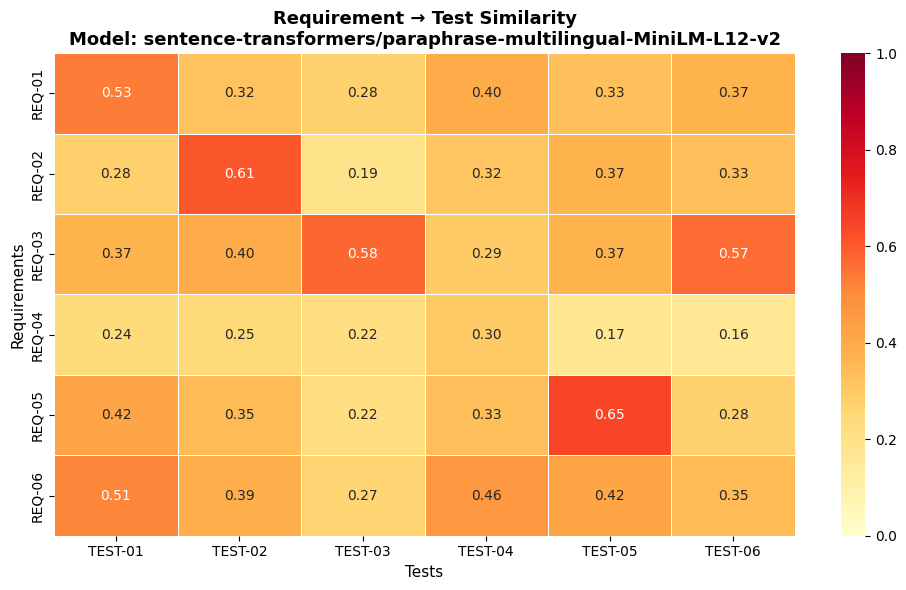

✅ Heatmap opgeslagen als similarity_heatmap.png


In [ ]:
# ── Stap 7: Visualiseer als heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    cosine_scores,
    xticklabels=test_labels,
    yticklabels=req_labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title(f'Requirement → Test Similarity\nModel: {MODEL_NAME}', fontsize=13, fontweight='bold')
ax.set_xlabel('Tests', fontsize=11)
ax.set_ylabel('Requirements', fontsize=11)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap opgeslagen als similarity_heatmap.png')

In [ ]:
# ── Stap 8: Beste match per requirement ───────────────────────────────────
THRESHOLD = 0.50  # ✏️ Pas aan: boven deze score = mogelijke match

print(f'Beste match per requirement (threshold: {THRESHOLD})\n')
print('-' * 70)

for i, req in enumerate(requirements):
    scores = cosine_scores[i]
    best_idx = np.argmax(scores)
    best_score = scores[best_idx]

    status = '✅ MATCH' if best_score >= THRESHOLD else '❌ GAP'

    print(f'{status} | Score: {best_score:.3f}')
    print(f'  REQ:  {req}')
    if best_score >= THRESHOLD:
        print(f'  TEST: {tests[best_idx]}')
    else:
        print(f'  TEST: geen match gevonden boven threshold')
    print()

Beste match per requirement (threshold: 0.5)

----------------------------------------------------------------------


NameError: name 'requirements' is not defined

In [ ]:
# ── Stap 9: Duplicate detectie tussen requirements ────────────────────────
DUPLICATE_THRESHOLD = 0.85  # ✏️ Pas aan

req_sim = util.cos_sim(req_embeddings, req_embeddings).cpu().numpy()

print(f'Mogelijke duplicates (threshold: {DUPLICATE_THRESHOLD})\n')
print('-' * 70)

found = False
for i in range(len(requirements)):
    for j in range(i + 1, len(requirements)):
        score = req_sim[i][j]
        if score >= DUPLICATE_THRESHOLD:
            found = True
            print(f'⚠️  Score: {score:.3f}')
            print(f'  A: {requirements[i]}')
            print(f'  B: {requirements[j]}')
            print()

if not found:
    print('Geen duplicates gevonden boven threshold.')
    print('Probeer een lagere threshold als je toch duplicates verwacht.')

Mogelijke duplicates (threshold: 0.85)

----------------------------------------------------------------------
Geen duplicates gevonden boven threshold.
Probeer een lagere threshold als je toch duplicates verwacht.


In [ ]:
# ── Stap 10: Vergelijk meerdere modellen ──────────────────────────────────
# Dit duurt even maar geeft een goed beeld van de verschillen

models_to_compare = [
    'all-MiniLM-L6-v2',
    'all-MiniLM-L12-v2',
    'BAAI/bge-small-en-v1.5',
    # 'all-mpnet-base-v2',        # ✏️ Uncomment voor meer modellen
    # 'paraphrase-multilingual-MiniLM-L12-v2',
]

results = []

for model_name in models_to_compare:
    print(f'\nTesten: {model_name}')

    m = SentenceTransformer(model_name)

    # Snelheid meten
    all_texts = requirements + tests
    start = time.time()
    embeddings = m.encode(all_texts, convert_to_tensor=True)
    elapsed = time.time() - start
    speed = len(all_texts) / elapsed

    # REQ-01 vs TEST-01 score (verwacht hoog)
    r1 = m.encode(requirements[0], convert_to_tensor=True)
    t1 = m.encode(tests[0], convert_to_tensor=True)
    match_score = util.cos_sim(r1, t1).item()

    # REQ-01 vs TEST-06 score (verwacht laag)
    t6 = m.encode(tests[5], convert_to_tensor=True)
    nomatch_score = util.cos_sim(r1, t6).item()

    # REQ-01 vs REQ-06 (NL duplicate, verwacht hoog)
    r6 = m.encode(requirements[5], convert_to_tensor=True)
    dup_score = util.cos_sim(r1, r6).item()

    results.append({
        'Model': model_name.split('/')[-1],
        'Dims': m.get_sentence_embedding_dimension(),
        'Snelheid (zin/s)': f'{speed:.0f}',
        'REQ01↔TEST01 (match)': f'{match_score:.3f}',
        'REQ01↔TEST06 (geen match)': f'{nomatch_score:.3f}',
        'REQ01↔REQ06 (NL dup)': f'{dup_score:.3f}',
    })
    print(f'  ✅ match: {match_score:.3f} | geen match: {nomatch_score:.3f} | NL dup: {dup_score:.3f} | {speed:.0f} zin/s')

print('\n' + '='*70)
print('VERGELIJKING OVERZICHT')
print('='*70)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


Testen: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ match: 0.523 | geen match: 0.190 | NL dup: 0.152 | 976 zin/s

Testen: all-MiniLM-L12-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  ✅ match: 0.830 | geen match: 0.671 | NL dup: 0.701 | 882 zin/s

VERGELIJKING OVERZICHT
            Model  Dims Snelheid (zin/s) REQ01↔TEST01 (match) REQ01↔TEST06 (geen match) REQ01↔REQ06 (NL dup)
 all-MiniLM-L6-v2   384              976                0.523                     0.190                0.152
all-MiniLM-L12-v2   384              874                0.518                     0.164                0.268
bge-small-en-v1.5   384              882                0.830                     0.671                0.701


## 💡 Wat kun je hieruit leren?

**Match score (REQ01↔TEST01):** Hoe goed herkent het model dat een requirement en test over hetzelfde gaan? Hoger = beter.

**Geen match score (REQ01↔TEST06):** Hoe goed onderscheidt het model niet-gerelateerde teksten? Lager = beter.

**NL duplicate score (REQ01↔REQ06):** Herkent het model dat een Nederlandse en Engelse requirement hetzelfde betekenen? Hoger = beter voor meertalige aanpak.

**Threshold bepalen:** Kijk naar de verdeling van scores — waar zit de natuurlijke grens tussen match en geen match?

---

### Volgende stap
Probeer je **eigen requirements en testdocumenten** in stap 3 in te vullen en kijk hoe het model reageert op jouw echte data!